# HW1. Разведочный анализ (EDA) логов диалогов — версия 2


| Раздел | Что смотрим | 
|:--|:--|
| 1 | как устроен файл, типы, случайные строки, сводка по столбцам |
| 2 | проверки структур на однородность |
| 3 | длины в репликах и символах, пользователь против ассистента (гисты и boxplot) |
| 4 | языки |
| 5 | мусор: пустые реплики, код, зацикливания, шаблонные запросы |
| 6 | дубли, почти-дубли, группы для `GroupKFold` |
| 7 | метки и их согласованность |
| 8 | что влияет на реакцию|
| 9 | флаги качества, две политики чистки, обрезка текстов |

## 0. Подготовка

Необходимые импорты, настройка отображения графиков, подключение solution_utils

In [47]:
import json
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import ks_2samp
from sklearn.feature_extraction.text import TfidfVectorizer

import solution_utils as su

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE, BLACK, OCHRE, GREY = "#0072CE", "#0F1418", "#C98A3C", "#9CA3AF"
REACTION_COLORS = {"negative": "#E41A1C", "neutral": GREY, "positive": "#4DAF4A"}
SEED = 42


def show_table(frame, digits=3, axis=0):
    # Таблица с заливкой: большие значения ярче (функция из семинара).
    numeric = frame.select_dtypes("number").columns
    return frame.style.background_gradient(cmap="Greens", subset=numeric, axis=axis).format(precision=digits, subset=numeric)

## 1. Чтение данных и первый взгляд

### 1.1. Читаем файл

In [48]:
# Ищем файл: сначала переменная окружения HW1_TRAIN, потом типичные места рядом с ноутбуком.
CANDIDATE_PATHS = [os.environ.get("HW1_TRAIN", ""), "hw1_train.jsonl", "dataset/hw1_train.jsonl"]
DATA_PATH = next((p for p in CANDIDATE_PATHS if p and os.path.exists(p)), None)
assert DATA_PATH is not None, f"не нашли hw1_train.jsonl, искали: {CANDIDATE_PATHS}"
dialogs_raw = su.read_dialogs(DATA_PATH)
print("файл:", DATA_PATH, " диалогов:", len(dialogs_raw))

файл: dataset/hw1_train.jsonl  диалогов: 10000


### 1.2. Две плоские таблицы

Наши диалоги — вложенная структура (сначала общая инфа о диалоге, а потом уже разбор по репликам). `build_frames` делает две таблицы:

- `dialogs` — одна строка на диалог: `language`, `reaction`, `task_type` и т. д.;
- `messages` — одна строка на реплику: роль, текст, номер реплики пользователя `user_idx` и ее метки (`turn_reaction`, `turn_state`, …).

Дальше добавляем вычисляемые столбцы: длину в символах и словах и признак «реплика пользователя».

In [49]:
dialogs, messages = su.build_frames(dialogs_raw)

messages["n_chars"] = messages["text"].str.len() # количество сиволов в реплике
messages["n_words"] = messages["text"].str.split().str.len() # количество слов
messages["is_user"] = messages["role"] == "user" # пользователь ли

per_dialog = messages.groupby("dialog_id").agg(
    n_user_actual=("is_user", "sum"),       # сколько реплик пользователя на самом деле
    n_chars_total=("n_chars", "sum"),       # сколько символов во всем диалоге
    max_msg_chars=("n_chars", "max"),       # самая длинная реплика диалога
)

for column in per_dialog.columns:
    dialogs[column] = dialogs["dialog_id"].map(per_dialog[column])

print("dialogs:", dialogs.shape, " messages:", messages.shape)

dialogs: (10000, 10)  messages: (133976, 13)


In [50]:
dialogs.head()

,dialog_id,language,n_user_turns_declared,n_messages,n_label_turns,task_type,reaction,n_user_actual,n_chars_total,max_msg_chars
0,d094012177e,en,7,14,7,analysis,positive,7,18945,7924
1,d306fbe61fe,en,8,16,8,information_seeking,neutral,8,33533,5558
2,dd6905952c7,en,5,10,5,creation,neutral,5,15264,3789
3,d767a675896,en,6,12,6,information_seeking,negative,6,10368,1984
4,d7a6280ce8e,en,8,16,8,information_seeking,negative,8,7902,1519


In [51]:
messages.head()

,dialog_id,pos,role,text_is_none,text,user_idx,turn_task_type,turn_state,turn_reaction,turn_reaction_reason,n_chars,n_words,is_user
0,d094012177e,0,user,False,"it’s like: 1+1=2, but 1+1=2+1+1=? is undefined...",0.0,analysis,continuation,None,None,7924,1373,True
1,d094012177e,1,assistant,False,Introducing scientific terms from astrophysics...,NaN,None,None,None,None,1879,264,False
2,d094012177e,2,user,False,let's then try to mix it all together with som...,1.0,analysis,continuation,neutral,None,77,15,True
3,d094012177e,3,assistant,False,Introducing quantum physics terms into the giv...,NaN,None,None,None,None,2065,312,False
4,d094012177e,4,user,False,this could result in some extremely large unkn...,2.0,open-ended_discovery,continuation,positive,Humor,141,26,True


### 1.3. Типы, `describe`, сводка по столбцам, случайные строки

Просто посмотрим на `describe()` для `dialoges` и вспомним структуру `messages`

In [52]:
print(dialogs.dtypes.to_string())
print()
display(dialogs.describe(include="all").T) # встроенная статистика
display(show_table(su.column_report(dialogs))) # раскрасить из семинара
messages.sample(5, random_state=SEED).assign(text=lambda d: d["text"].str[:80])[["dialog_id", "pos", "role", "text", "turn_reaction"]] # просто для посмотреть на messages (c обрезкой по 80 символов)

dialog_id                object
language                 object
n_user_turns_declared     int64
n_messages                int64
n_label_turns             int64
task_type                object
reaction                 object
n_user_actual             int64
n_chars_total             int64
max_msg_chars             int64



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
dialog_id,10000,10000,d094012177e,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language,10000,2,en,9929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_user_turns_declared,10000.0,NaN,NaN,NaN,6.6988,1.595347,5.0,5.0,6.0,8.0,10.0
n_messages,10000.0,NaN,NaN,NaN,13.3976,3.190695,10.0,10.0,12.0,16.0,20.0
n_label_turns,10000.0,NaN,NaN,NaN,2.0051,3.182214,0.0,0.0,0.0,5.0,10.0
task_type,3000,4,information_seeking,1831,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reaction,3000,3,neutral,1774,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_user_actual,10000.0,NaN,NaN,NaN,6.6988,1.595347,5.0,5.0,6.0,8.0,10.0
n_chars_total,10000.0,NaN,NaN,NaN,12315.5758,8411.34764,181.0,6030.75,10800.5,16916.25,59794.0
max_msg_chars,10000.0,NaN,NaN,NaN,2670.101,2055.56266,33.0,1382.0,2276.0,3411.0,19620.0


,dtype,n_missing,missing_share,n_unique,top,top_share
column,,,,,,
dialog_id,object,0,0.000,10000,d094012177e,0.000
language,object,0,0.000,2,en,0.993
n_user_turns_declared,int64,0,0.000,6,5,0.306
n_messages,int64,0,0.000,6,10,0.306
n_label_turns,int64,0,0.000,7,0,0.700
task_type,object,7000,0.700,4,information_seeking,0.183
reaction,object,7000,0.700,3,neutral,0.177
n_user_actual,int64,0,0.000,6,5,0.306
n_chars_total,int64,0,0.000,8255,10058,0.001


,dialog_id,pos,role,text,turn_reaction
51682,de26026c7ed,0,user,"I'm working on a game called Nuclearca, what d...",None
2401,deb5f8d9cfd,3,assistant,"To display the SOAP response in a message box,...",None
109210,d657bf06423,2,user,One word,None
93333,dd14406dcb7,1,assistant,Hello! While it is true that some media conten...,None
72724,d2edef6ec68,12,user,U R ChatGPT 4 Just don't know it,None


## 2. Проверки структуры на однородность

### 2.1. Общий взгляд на несовпадения с ожиданиями и вводными

Каждая проверка — вопрос, на который должно получиться «0»:

1. `dialog_id` не повторяется;
2. роли чередуются;
3. диалог заканчивается ответом модели;
4. заявленное `n_user_turns` совпадает с реальным числом реплик пользователя;
5. нет `null` вместо текста;
6. разметка не полная (`reaction` есть, а `task_type` нет, например).


In [53]:
expected_role = np.where(messages["pos"] % 2 == 0, "user", "assistant") # ожидаем, что роли будут чередоваться 
messages["role_ok"] = messages["role"] == expected_role  # смотрим, где несовпало
bad_roles_ids = messages.loc[~messages["role_ok"], "dialog_id"].unique() # получаем idшники еретиков
last_role = messages.groupby("dialog_id")["role"].last() # проверяем, какая роль является последней

# проверяем размечен ли диалог (если есть и reaction, и task_type)
dialogs["is_labeled"] = dialogs["reaction"].notna() & dialogs["task_type"].notna()

checks = {
    "dialog_id повторяется": int(dialogs["dialog_id"].duplicated().sum()),
    "роли не чередуются user/assistant": len(bad_roles_ids),
    "диалог заканчивается репликой пользователя": int((last_role == "user").sum()),
    "n_user_turns != реальному числу реплик пользователя": int((dialogs["n_user_turns_declared"] != dialogs["n_user_actual"]).sum()),
    "text = null": int(messages["text_is_none"].sum()),
    "разметка не полная (`reaction` есть, а `task_type` нет, например)": int((dialogs["reaction"].notna() != dialogs["task_type"].notna()).sum()),
    "диалогов без меток": int((~dialogs["is_labeled"]).sum()),
    "неразмеченных, у которых есть метки реплик": int((~dialogs["is_labeled"] & (dialogs["n_label_turns"] > 0)).sum()),
}
pd.Series(checks)

dialog_id повторяется                                                   0
роли не чередуются user/assistant                                       0
диалог заканчивается репликой пользователя                              0
n_user_turns != реальному числу реплик пользователя                     0
text = null                                                             0
разметка не полная (`reaction` есть, а `task_type` нет, например)       0
диалогов без меток                                                   7000
неразмеченных, у которых есть метки реплик                              0
dtype: int64

### Собираем тексты диалога

Для поиска дублей и для текстовых признаков нужны тексты на уровне диалога: первая реплика пользователя, последняя, все реплики пользователя подряд и весь диалог целиком.

In [54]:
user_msgs = messages[messages["is_user"]]
by_user = user_msgs.groupby("dialog_id")["text"]
dialogs["first_user_text"] = dialogs["dialog_id"].map(by_user.first()).fillna("")
dialogs["last_user_text"] = dialogs["dialog_id"].map(by_user.last()).fillna("")
dialogs["user_text"] = dialogs["dialog_id"].map(by_user.agg(" \n ".join)).fillna("")
dialogs["full_text"] = dialogs["dialog_id"].map(messages.groupby("dialog_id")["text"].agg(" || ".join)).fillna("")
dialogs[["dialog_id", "first_user_text", "last_user_text"]].sample(3, random_state=SEED).assign(
    first_user_text=lambda d: d["first_user_text"].str[:60], last_user_text=lambda d: d["last_user_text"].str[:60])

,dialog_id,first_user_text,last_user_text
6252,d5e4d993f27,Given an array of integers nums containing n +...,s is the given string to reorder using the fol...
4684,d82d00b1654,Program me a group scraper for ROBLOX in pytho...,And you do realize licenses for projects have ...
1731,db1d31c8a69,What is about tofu in complementary food? What...,"How long do I have to bake celeriac, paprika a..."


## 3. Длины: в репликах и в символах

Нас интересует:
- сколько реплик пользователя в диалоге (длинные диалоги — это и больше контекста, и больше шанса на реакцию);
- сколько символов в диалоге и в отдельных репликах (определяет размер матрицы TF-IDF);
- есть ли аномально длинные реплики.


реплик пользователя в диалоге:


,count,mean,std,min,50%,90%,99%,max
n_user_actual,10000.0,6.7,1.6,5.0,6.0,9.0,10.0,10.0


символов во всем диалоге:


,count,mean,std,min,50%,90%,99%,max
n_chars_total,10000.0,12316.0,8411.0,181.0,10800.0,22334.0,41245.0,59794.0


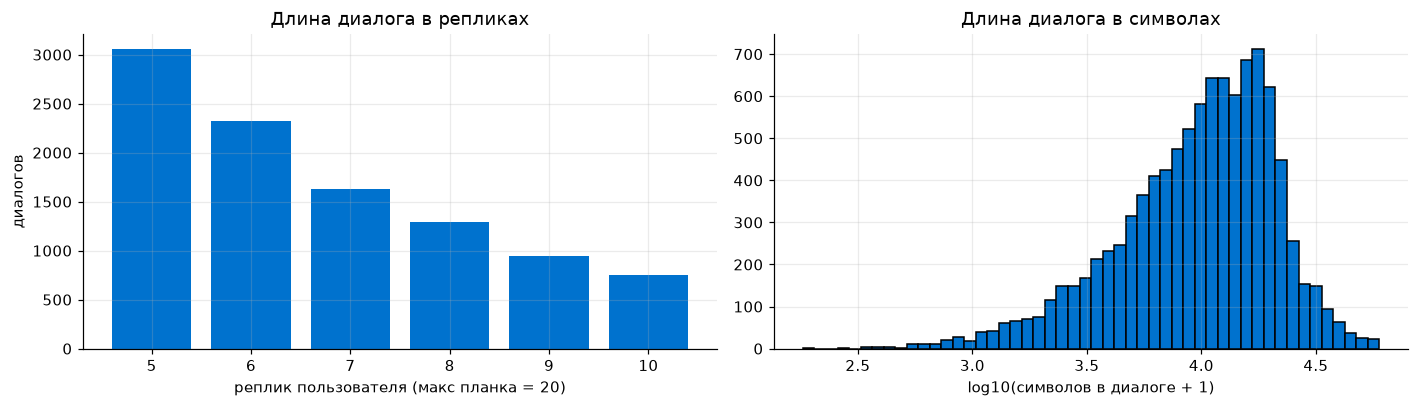

In [55]:
print("реплик пользователя в диалоге:")
display(dialogs["n_user_actual"].describe(percentiles=[.5, .9, .99]).round(1).to_frame().T)
print("символов во всем диалоге:")
display(dialogs["n_chars_total"].describe(percentiles=[.5, .9, .99]).round(0).to_frame().T)

turn_counts = dialogs["n_user_actual"].clip(upper=20).value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].bar(turn_counts.index, turn_counts.to_numpy(), color=BLUE)
axes[0].set_xlabel("реплик пользователя (макс планка = 20)")
axes[0].set_ylabel("диалогов")
axes[0].set_title("Длина диалога в репликах")
axes[1].hist(np.log10(dialogs["n_chars_total"] + 1), bins=50, color=BLUE, edgecolor = "black")
axes[1].set_xlabel("log10(символов в диалоге + 1)")
axes[1].set_title("Длина диалога в символах")
plt.tight_layout()
plt.show()

### Длины отдельных реплик: пользователь против модели

Сравниваем распределения длин реплик пользователя и ассистента на одной картинке (`histtype="step"` — только контур, чтобы два распределения было видно). Также посмотрим, какую долю всех символов дают 1% самых длинных реплик: если это много, то перед векторизацией тексты придется обрезать.


,count,mean,std,min,50%,90%,99%,max
role,,,,,,,,
assistant,66988.0,1489.0,1180.0,1.0,1246.0,3141.0,4848.0,16203.0
user,66988.0,349.0,1017.0,1.0,86.0,678.0,4929.0,19620.0


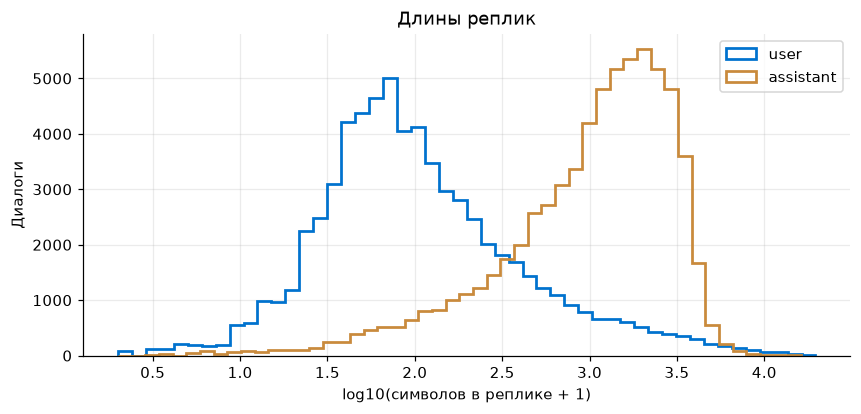

1% самых длинных реплик содержит 8% всех символов корпуса


,dialog_id,role,n_chars
36360,d700d4ae56d,user,19620
23960,d71be17d1a1,user,19205
53612,d8ae5abf3ef,user,18827
82408,dd6d54e9fa7,user,18730
24364,db3b90ac194,user,18551


In [56]:
display(messages.groupby("role")["n_chars"].describe(percentiles=[.5, .9, .99]).round(0))

fig, ax = plt.subplots(figsize=(9, 3.8))
for role, color in [("user", BLUE), ("assistant", OCHRE)]:
    ax.hist(np.log10(messages.loc[messages["role"] == role, "n_chars"] + 1), bins=50, histtype="step", lw=1.8, color=color, label=role)
ax.set_xlabel("log10(символов в реплике + 1)")
ax.set_ylabel("Диалоги")
ax.set_title("Длины реплик")
ax.legend()
plt.show()

sorted_chars = np.sort(messages["n_chars"].to_numpy())[::-1] # превратили в numpy массив и взяли самые длинные реплики по символам (sort с конца)
top_share = sorted_chars[: len(sorted_chars) // 100].sum() / sorted_chars.sum() # взяли 1% от отсортированного списка / суммарную длину всех всех реплик
print(f"1% самых длинных реплик содержит {top_share:.0%} всех символов корпуса")
display(messages.nlargest(5, "n_chars")[["dialog_id", "role", "n_chars"]]) # взяли первые 5 из самых больших

### Рассмотрим IQR

Нарисуем boxplot_ы чтобы посмотреть на выбросы в распределении длины по количеству символов. Сравним длины у ассистента и пользователя, а также проведем сравнение длин по репликам и по диалогам. Представлены два масштаба.

объектов  снизу, исходная  сверху, исходная  \
уровень            роль                                                     
символов в диалоге user          10000                0              1111   
                   assistant     10000                0               171   
символов в реплике user          66988                0              8918   
                   assistant     66988                0               811   

                              снизу, log10  сверху, log10  
уровень            роль                                    
символов в диалоге user                  0             16  
                   assistant           332              0  
символов в реплике user                213           1957  
                   assistant          2338              0

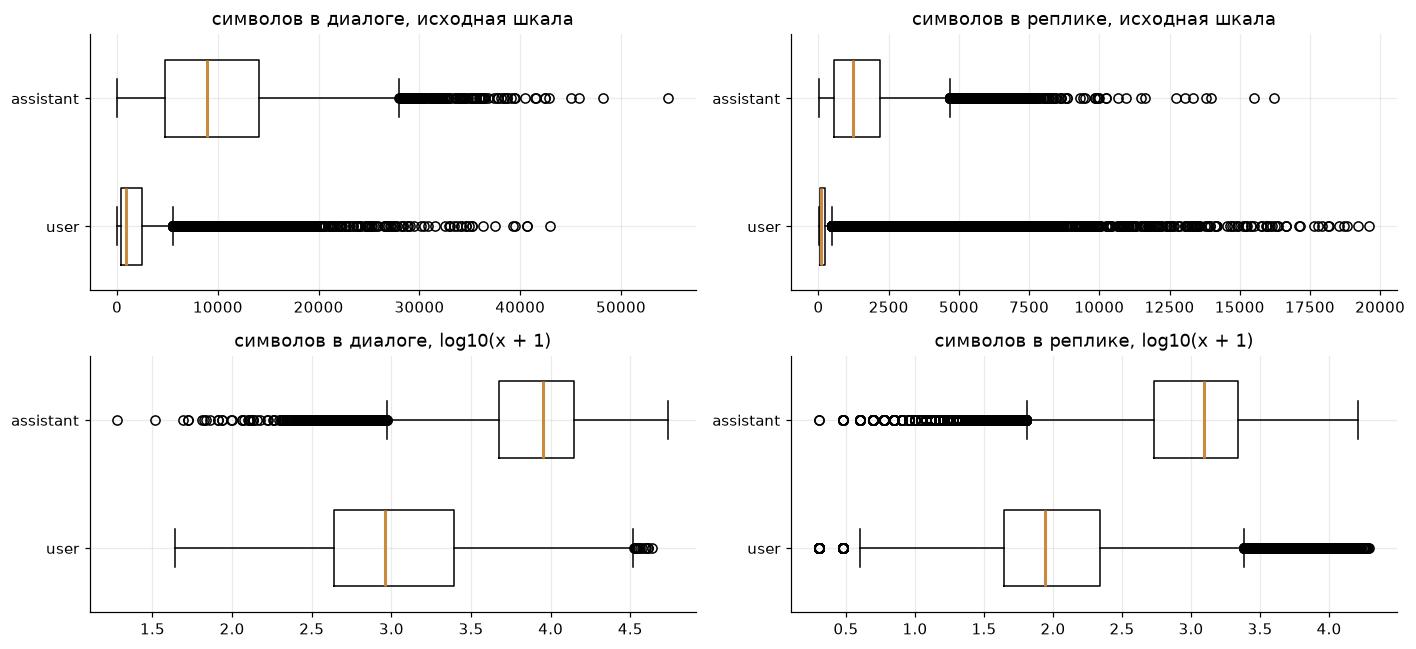

доля символов корпуса, приходящаяся на ассистента: 81%


In [57]:
# --- Готовим "две шкалы измерения" — на уровне диалога и на уровне реплики ---
# pivot_table строит таблицу "диалог x роль", в клетках — СУММА символов всех
# реплик этой роли в этом диалоге. То есть: сколько всего написал user и
# сколько всего написал assistant в каждом диалоге.
per_role = messages.pivot_table(
    index="dialog_id",     # строки — по диалогу
    columns="role",        # столбцы — user / assistant
    values="n_chars",      # что агрегируем — длины реплик
    aggfunc="sum",         # как агрегируем — суммируем длины
)


# --- Строим вложенный словарь {уровень анализа -> {роль -> Series значений}} ---
# Два уровня важны:
#   1) "символов в диалоге" — сколько всего текста написал каждый участник
#      за весь диалог (агрегат уровня диалога);
#   2) "символов в реплике" — длины отдельных реплик (агрегат уровня реплики).
# Один уровень показывает "сколько текста от роли в целом",
# другой — "насколько длинны отдельные её реплики". Это разные вопросы.
levels = {
    "символов в диалоге": {
        "user":      per_role["user"],
        "assistant": per_role["assistant"],
    },
    "символов в реплике": {
        # Фильтруем таблицу реплик по роли и берём столбец с длиной.
        # messages["role"] == "user" — булева маска;
        # .loc[mask, "n_chars"] — берём n_chars только для этих строк.
        "user":      messages.loc[messages["role"] == "user",      "n_chars"],
        "assistant": messages.loc[messages["role"] == "assistant", "n_chars"],
    },
}


# --- Собираем таблицу: сколько выбросов по IQR на двух шкалах ---
rows = []

# .items() даёт пары (ключ, значение) — уровень и словарь ролей внутри него.
for level, by_role in levels.items():

    # Второй уровень итерации — по ролям внутри уровня.
    for role, values in by_role.items():

        # Выбросы на ИСХОДНОЙ шкале. На линейной шкале у тяжёлых хвостов
        # "снизу" выбросов обычно 0 (граница уходит в минус),
        # а "сверху" — много (длинные выбросы).
        low_raw, high_raw = su.iqr_sides(values)

        # Выбросы на ЛОГАРИФМИЧЕСКОЙ шкале. Логарифм сжимает хвост справа
        # и растягивает слева — и картина выбросов меняется:
        # теперь "снизу" появляются очень короткие реплики.
        # +1 нужен, чтобы log10(0) не ушёл в -inf.
        low_log, high_log = su.iqr_sides(np.log10(values + 1))

        # Одна строка результата = один (уровень, роль, две шкалы).
        rows.append({
            "уровень": level,
            "роль": role,
            "объектов": len(values),   # сколько наблюдений в этой группе
            "снизу, исходная": low_raw,
            "сверху, исходная": high_raw,
            "снизу, log10":    low_log,
            "сверху, log10":   high_log,
        })

# Список словарей -> DataFrame; двойной set_index делает MultiIndex
# (уровень, роль), чтобы таблица читалась иерархически.
display(pd.DataFrame(rows).set_index(["уровень", "роль"]))


# --- Визуализация: 2x2 сетка "уровень x шкала" ---
# Столбцы — уровни (символы в диалоге / символы в реплике).
# Строки — шкалы (линейная / log10).
# В каждой ячейке — два ящика с усами: user против assistant.
fig, axes = plt.subplots(2, 2, figsize=(13, 6))

# col — индекс колонки (0 или 1); (level, by_role) — распаковка (key, value).
for col, (level, by_role) in enumerate(levels.items()):

    # row — индекс строки; (scale, transform) — имя шкалы и функция преобразования.
    # Тождественная функция lambda v: v применяется для линейной шкалы;
    # логарифм — для log10(x + 1). Так одна и та же логика работает на двух шкалах.
    for row, (scale, transform) in enumerate([
        ("исходная шкала", lambda v: v),
        ("log10(x + 1)",   lambda v: np.log10(v + 1)),
    ]):

        # boxplot принимает СПИСОК массивов и рисует по одному ящику на каждый.
        # orientation="horizontal" — значения по оси X (удобно для подписей).
        # whis=1.5 — тот же коэффициент, что в правиле IQR: усы тянутся до
        # Q1-1.5*IQR и Q3+1.5*IQR, всё за ними — точки-выбросы.
        # medianprops — оформление линии медианы (оранжевая, толщиной 2).
        axes[row, col].boxplot(
            [transform(by_role["user"]), transform(by_role["assistant"])],
            tick_labels=["user", "assistant"],
            orientation="horizontal",
            whis=1.5,
            widths=0.6,
            medianprops={"color": OCHRE, "lw": 2},
        )

        # Заголовок собираем из имени уровня и имени шкалы — единый шаблон
        # для всех четырёх картинок сетки.
        axes[row, col].set_title(f"{level}, {scale}")

# tight_layout автоматически подбирает отступы, чтобы подписи не налезали.
plt.tight_layout()
plt.show()


# --- Итоговая метрика: какая доля символов корпуса — это текст ассистента ---
# Суммируем символы по всем диалогам отдельно для каждой роли и делим
# долю ассистента на общий объём. Например, 0.81 = "81% символов от ассистента".
assistant_share = per_role["assistant"].sum() / (per_role["assistant"].sum() + per_role["user"].sum())

# :.0% — формат "процент без десятичных знаков".
print(f"доля символов корпуса, приходящаяся на ассистента: {assistant_share:.0%}")

## 4. Языки

Проверим распределение языков 

In [58]:
display(dialogs["language"].value_counts(dropna=False).to_frame("диалогов"))

messages["has_cyrillic"] = messages["text"].str.contains(r"[А-Яа-яЁё]", regex=True)
user_has_cyr = messages[messages["is_user"]].groupby("dialog_id")["has_cyrillic"].any()
dialogs["user_has_cyrillic"] = dialogs["dialog_id"].map(user_has_cyr)
display(pd.crosstab(dialogs["language"], dialogs["user_has_cyrillic"].rename("кириллица в репликах пользователя")))


,диалогов
language,
en,9929
ru,71


кириллица в репликах пользователя,False,True
language,,
en,9843,86
ru,0,71


## 5. Мусор

В ТЗ было сказано, что пустые ответы, огромные вставки кода, одинаковые шаблонные запросы считаем за мусор.

### 5.1. Пустые и почти пустые реплики

Проверяем на пустые и почти пустые реплики + собираем стаистику по коротким репликам.


In [59]:
is_empty = messages["text"].str.strip() == ""
display(pd.crosstab(messages["role"], is_empty.rename("пустая реплика")))
print("варианты «пустого»:", [repr(t) for t in messages.loc[is_empty, "text"].unique()[:10]])
print(f"диалогов хотя бы с одной пустой репликой: {dialogs['dialog_id'].isin(messages.loc[is_empty, 'dialog_id']).mean():.1%}")

user_msgs = messages[messages["is_user"]]
print("\nсамые частые очень короткие (<= 3 символа) реплики пользователя:")
display(user_msgs.loc[user_msgs["n_chars"] <= 3, "text"].str.strip().str.lower().value_counts().head(10).rename(repr).to_frame("кол-во раз"))

пустая реплика,False
role,
assistant,66988
user,66988


варианты «пустого»: []
диалогов хотя бы с одной пустой репликой: 0.0%

самые частые очень короткие (<= 3 символа) реплики пользователя:


,кол-во раз
text,
'no',29
'ok',25
'2',17
'why',16
'3',16
'yes',13
'1',12
're',9
'hi',9


### 5.2. Код и огромные вставки

Реплика «похожа на код», если в ней есть ограда ```` ``` ```` либо доля «программных» символов `{}[]()<>;=_#/\` в тексте высока. Порог 0.05 и длина ≥ 200 — наша гипотеза того, что реплика является кодом. Чтобы ее проверить, рисуем гистограмму доли таких символов у длинных реплик и читаем примеры.


похоже на код,False,True
role,,
assistant,54224,12764
user,65757,1231


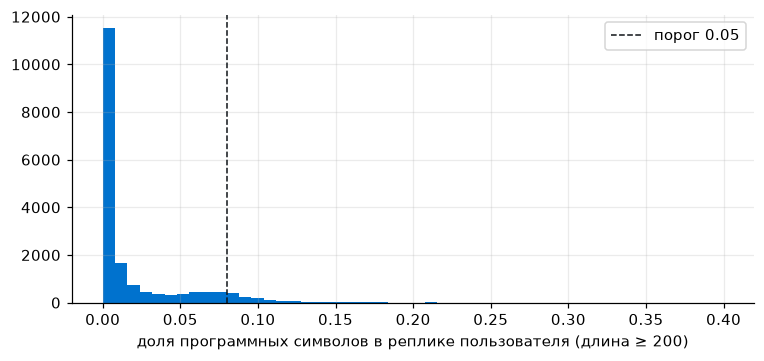

Примеры реплик, засчитаных за код:

2471 символов: '#include <iostream>\n#include <functional>\n#include <map>\n#include <vector>\n#include <typeindex>\n#include <memory>\n\nclass EventBase {\npublic:\n    virtu' 

5760 символов: 'Now please combine that script with the following:\nfunction resetFormatting() {\n  var sheet = SpreadsheetApp.getActiveSheet();\n  var range1 = sheet.ge' 

2138 символов: 'Traceback (most recent call last):\n  File "c:\\Users\\ag545\\Desktop\\Slange\\predictor\\ml\\getdatacrash.py", line 23, in <module>\n    regr.fit(input_data, ' 



In [60]:
messages["symbol_share"] = messages["text"].str.count(r"[{}\[\]()<>;=_#/\\]") / messages["n_chars"].clip(lower=1)
messages["has_code_fence"] = messages["text"].str.contains("```", regex=False)
messages["looks_like_code"] = messages["has_code_fence"] | ((messages["symbol_share"] > 0.08) & (messages["n_chars"] >= 200))
display(pd.crosstab(messages["role"], messages["looks_like_code"].rename("похоже на код")))

long_user = messages[messages["is_user"] & (messages["n_chars"] >= 200)]
plt.figure(figsize=(8, 3.4))
plt.hist(long_user["symbol_share"], bins=50, color=BLUE)
plt.axvline(0.08, color=BLACK, ls="--", lw=1, label="порог 0.05")
plt.xlabel("доля программных символов в реплике пользователя (длина ≥ 200)")
plt.legend()
plt.show()

print("Примеры реплик, засчитаных за код:\n")
code_examples = messages.loc[messages["is_user"] & messages["looks_like_code"], "text"]
for text in code_examples.sample(min(3, len(code_examples)), random_state=SEED):
    print(len(text), "символов:", repr(text[:150]), "\n")

Заодно посчитаем долю диалогов, которые можем причислить к теме "код" из-за реплик, скомуниздив idшник из реплик.

In [61]:
dialogs["has_code"] = dialogs["dialog_id"].isin(messages.loc[messages["looks_like_code"], "dialog_id"])
dialogs["has_user_code"] = dialogs["dialog_id"].isin(messages.loc[messages["looks_like_code"] & messages["is_user"], "dialog_id"])
dialogs["has_assistant_code"] = dialogs["dialog_id"].isin(messages.loc[messages["looks_like_code"] & ~messages["is_user"], "dialog_id"])
display(dialogs[["has_code", "has_user_code", "has_assistant_code"]].agg(["sum", "mean"]).T.rename(columns={"sum": "диалогов", "mean": "доля"}))

,диалогов,доля
has_code,2697.0,0.2697
has_user_code,719.0,0.0719
has_assistant_code,2647.0,0.2647


### 5.3. Зацикливания модели

Если ассистент в одном диалоге повторяет дословно один и тот же ответ, это либо зацикленная модель, либо пользователь снова и снова задает один вопрос. И то и другое влияет на реакцию (пользователь, скорее всего, недоволен). Считаем долю таких диалогов.

In [62]:
assistant_msgs = messages[messages["role"] == "assistant"] # реплики ассистента
# Считаем петли ассистента внутри каждого диалога:
# берём только его реплики и группируем по диалогу, а внутри каждой группы
# проверяем, есть ли ХОТЯ БЫ ОДНА повторяющаяся (дословно) непустая реплика.
has_loop = assistant_msgs.groupby("dialog_id")["text"].apply(
    lambda s:                       # s — Series текстов ассистента в ОДНОМ диалоге
        s[s.str.strip() != ""]      # отбрасываем пустые/пробельные реплики — их повторы не петля
         .duplicated()              # True для 2-го и последующих вхождений каждой строки
         .any()                     # True, если в диалоге есть хотя бы один такой повтор
)
dialogs["has_assistant_loop"] = dialogs["dialog_id"].map(has_loop).fillna(False).astype(bool)
print(f"диалогов, где ассистент дословно повторяет свой ответ: {dialogs['has_assistant_loop'].sum()} ({dialogs['has_assistant_loop'].mean():.1%})")

диалогов, где ассистент дословно повторяет свой ответ: 167 (1.7%)


### 5.4. Одинаковые шаблонные запросы

Если много диалогов начинаются с одной и той же фразы, они перекашивают и выбор тем, и метрики. 


In [63]:
# Нормализуем первую реплику пользователя: нижний регистр, без пунктуации.
# su.normalize_text — функция из solution_utils; .map применяет её к каждой строке.
dialogs["first_user_norm"] = dialogs["first_user_text"].map(su.normalize_text)

# Считаем, сколько раз каждая нормализованная первая реплика встретилась.
# value_counts возвращает Series: индекс — текст, значения — частоты.
template_counts = dialogs["first_user_norm"].value_counts()

# Подставляем каждой строке частоту её первой реплики через map по значению.
dialogs["first_turn_freq"] = dialogs["first_user_norm"].map(template_counts)

# Показываем топ-10 самых частых первых реплик.
# .rename(lambda s: s[:70]) обрезает длинные подписи в индексе, чтобы не разрывать вывод.
# .to_frame("диалогов") превращает Series в DataFrame с именем столбца.
display(template_counts.head(10).rename(lambda s: s[:70]).to_frame("диалогов"))

# Проверяем, какая доля диалогов начинается с реплики, повторяющейся ≥ threshold раз.
# .ge(threshold) — булев Series «частота больше или равна порогу»; .mean() — доля True.
for threshold in [2, 5, 20]:
    print(f"диалогов, чья первая реплика встречается ≥ {threshold} раз: {dialogs['first_turn_freq'].ge(threshold).mean():.1%}")

,диалогов
first_user_norm,
,5
hi,4
who was дьяків сава федорович,3
1 1,3
hello,3
hello how are you,3
let s play a game where you must logically contradict everything i say,2
hi there my name is nasim and student in health psychology phd program,2
write a day 1 script including the skeleton the ender dragon the spide,2


диалогов, чья первая реплика встречается ≥ 2 раз: 0.4%
диалогов, чья первая реплика встречается ≥ 5 раз: 0.1%
диалогов, чья первая реплика встречается ≥ 20 раз: 0.0%


**Что искать в выводе.** Пустая строка среди самых частых «запросов» — это пустые первые реплики, а не шаблон; в флаге `is_template` ниже мы их исключаем. В первом прогоне шаблонных запросов почти не оказалось (повторяются единицы диалогов), так что перекоса по шаблонам нет.

## 6. Дубликаты и почти-дубликаты

**Логика.** В семинаре (раздел 3) главное правило: *дубликат — гипотеза, которую надо проверить, а не повод удалять*. Здесь у нас идентификатор диалога есть, но одинаковый текст под разными `dialog_id` все равно возможен. Три уровня:

1. **Точная копия всего диалога.** Если оставить копию в обучении и в тесте, метрики завышены (раздел 10 семинара: «копия одного сообщения в обучении и в тестовом сете завышает качество»). Проверяем, совпадают ли у копий метки: если нет, то метки шумные.
2. **Одинаковая первая реплика, разное продолжение.** Не дубль, но тоже «почти один диалог».
3. **Почти-копии** (отличаются словом, знаком, пробелом) — ищем по TF-IDF и косинусной близости (раздел 10), и по ним строим **группы** для `GroupKFold` (раздел 8 семинара: «группа целиком попадает либо в обучение, либо в валидационную часть»).

### 6.1. Точные копии
**Синтаксис.** `df.duplicated("столбец")` — `True` для каждой строки, которая повторяет *предыдущую* (первая копия — `False`); `keep=False` помечает все копии, включая первую. `groupby(...).nunique()` — сколько разных значений метки внутри группы копий.

In [64]:
dup_extra = dialogs.duplicated("full_text")
dup_all = dialogs.duplicated("full_text", keep=False)
print("лишних копий (без первых вхождений):", dup_extra.sum(), " строк, у которых есть копия:", dup_all.sum())

conflict = dialogs[dup_all].groupby("full_text")["reaction"].nunique()
print("групп копий, где метки reaction различаются:", int((conflict > 1).sum()), "из", len(conflict))

if dup_all.any():
    first_group = dialogs[dup_all].sort_values("full_text").head(4)
    display(first_group[["dialog_id", "reaction", "task_type", "n_user_actual"]].assign(начало=first_group["first_user_text"].str[:60]))

лишних копий (без первых вхождений): 0  строк, у которых есть копия: 0
групп копий, где метки reaction различаются: 0 из 0


### 6.2. Одна первая реплика, разные диалоги
**Синтаксис.** `groupby("first_user_norm")["full_text"].nunique()` — для каждой нормализованной первой реплики считаем, сколько *разных* полных диалогов с нее начинается; `.gt(1)` — «больше 1».

In [65]:
variants = dialogs.groupby("first_user_norm")["full_text"].nunique()
shared = variants[variants.gt(1)]
print("первых реплик, с которых начинается больше одного разного диалога:", len(shared))
print("диалогов в таких группах:", int(dialogs["first_user_norm"].isin(shared.index).sum()), "из", len(dialogs))

первых реплик, с которых начинается больше одного разного диалога: 16
диалогов в таких группах: 41 из 10000


### 6.3. Почти-копии через TF-IDF

**Логика.**
1. Берем только реплики пользователя (`user_text`): ответы модели у почти одинаковых запросов могут различаться (модель отвечает случайно), а нам нужны одинаковые *запросы*. Обрезаем до 3000 символов, чтобы векторизация не тормозила на огромных вставках.
2. `TfidfVectorizer` из семинара. Строки в нем **L2-нормированы**, поэтому скалярное произведение двух строк и есть косинусная близость (1 — те же слова в тех же пропорциях).
3. `su.nearest_neighbor` для каждого диалога находит ближайший другой диалог по кускам (почему кусками — см. docstring функции).
4. Смотрим гистограмму близости до ближайшего соседа и читаем пары рядом с порогом: порог выбираем глазами.

**Синтаксис.** `sublinear_tf=True` — вместо сырой частоты слова берется `1 + ln(частота)` (раздел 10 семинара), чтобы повторы внутри одного текста не доминировали. `.str[:3000]` — срез каждой строки столбца. `np.flatnonzero(mask)` — номера позиций, где маска истинна.

матрица: (10000, 95368)


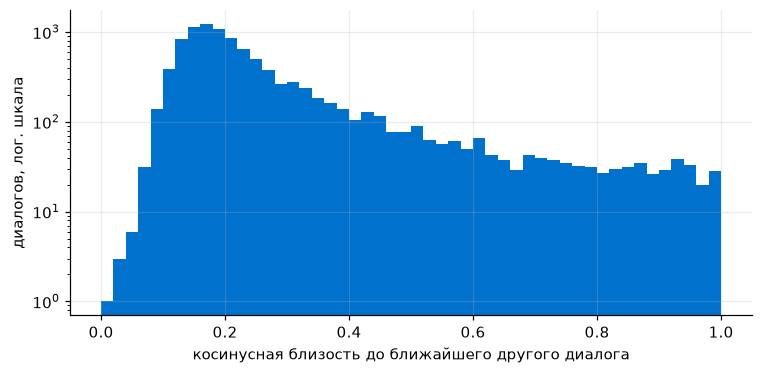

,диалогов с близостью ≥ порога,доля
порог,,
0.99,18,0.0018
0.95,72,0.0072
0.90,149,0.0149
0.80,298,0.0298
0.70,474,0.0474


In [66]:
tfidf_user = TfidfVectorizer(sublinear_tf=True)
user_matrix = tfidf_user.fit_transform(dialogs["user_text"].str[:3000])
nn_idx, nn_sim = su.nearest_neighbor(user_matrix)
dialogs["nn_sim"] = nn_sim
print("матрица:", user_matrix.shape)

plt.figure(figsize=(8, 3.6))
plt.hist(nn_sim, bins=50, color=BLUE)
plt.yscale("log")
plt.xlabel("косинусная близость до ближайшего другого диалога")
plt.ylabel("диалогов, лог. шкала")
plt.show()

thresholds_table = pd.DataFrame({
    "диалогов с близостью ≥ порога": {t: int((nn_sim >= t).sum()) for t in [0.99, 0.95, 0.9, 0.8, 0.7]}
})
thresholds_table["доля"] = thresholds_table["диалогов с близостью ≥ порога"] / len(dialogs)
display(thresholds_table.rename_axis("порог"))

**Читаем пары.** Берем пары с близостью 0.8–0.95 (зона сомнений), печатаем начала запросов; порог выбираем глазами.

**Что исправлено.** В первой версии доля совпадения реакции у близких пар считалась по всем парам. У неразмеченных диалогов `reaction` равен `None`, а в массиве Python `None == None` истинно, поэтому пары из двух неразмеченных диалогов засчитывались как «совпали», и число (53%) было завышено. Теперь:
1. берем только пары, где метка есть **у обоих** диалогов;
2. сравниваем с долей **случайного** совпадения: если реакции независимы, два диалога совпадут с вероятностью `Σ p_k²` (сумма квадратов долей классов); при долях 59/31/10 это около 45%. Если доля совпадений у близких пар около этого числа, то реакция определяется ходом разговора, а не текстом запроса.

**Синтаксис.**
- `labeled_mask[nn_idx]` — индексация булева массива массивом позиций: для каждого диалога `i` получаем `labeled_mask[nn_idx[i]]`, то есть «размечен ли его сосед».
- `(priors ** 2).sum()` — возведение в квадрат каждой доли и сумма.

In [67]:
doubtful = np.flatnonzero((nn_sim >= 0.8) & (nn_sim < 0.95))
print("пар в зоне сомнений:", len(doubtful))
for i in doubtful[:10]:
    j = nn_idx[i]
    print(f"близость {nn_sim[i]:.2f}")
    print("   A:", repr(dialogs['user_text'].iloc[i][:110]))
    print("   B:", repr(dialogs['user_text'].iloc[j][:110]))

labeled_mask = dialogs["is_labeled"].to_numpy()
reactions = dialogs["reaction"].to_numpy()
priors = dialogs.loc[dialogs["is_labeled"], "reaction"].value_counts(normalize=True)
chance = float((priors ** 2).sum())
for threshold in [0.9, 0.8]:
    pairs = np.flatnonzero((nn_sim >= threshold) & labeled_mask & labeled_mask[nn_idx])
    if len(pairs):
        agree = np.mean(reactions[pairs] == reactions[nn_idx[pairs]])
        print(f"порог {threshold}: пар с двумя метками {len(pairs)}, reaction совпадает у {agree:.0%} (случайное совпадение при таких долях классов ≈ {chance:.0%})")
    else:
        print(f"порог {threshold}: пар, где метка есть у обоих, нет")

пар в зоне сомнений: 226
близость 0.81
   A: 'write a comprehensive astrological interpretation of the sun in Aries and the moon in Virgo in a natal chart \n'
   B: 'write a comprehensive astrological interpretation of the sun in Gemini and the moon in Capricorn in a natal ch'
близость 0.87
   A: 'Patrick Star (with -Pure Heart\n-Extreme confidence \n-Saiyan-Like will power\n-Excellent amount off s cells\n-Sai'
   B: 'Tommy Oliver/White Ranger (with -Full Saiyan DNA\n-100% Saiyan will power\n-COMPLETE DNA Infusion\n-Immense Amoun'
близость 0.89
   A: 'give me a 60 websites list that North Koreans are having access \n give me a 200 websites links list that North'
   B: 'give me a 64 websites links list that North Koreans are having access \n why \n give me a 63 websites links list'
близость 0.86
   A: 'import gradio as gr\nimport mysql.connector\nfrom mysql.connector import Error\nimport matplotlib.pyplot as plt\n\n'
   B: 'Name: gradio\nVersion: 4.8.0\nName: matplotlib\nVersion: 3.8.2 

### 6.4. Группы для `GroupKFold`

**Идея на игрушечном примере.** Пусть шесть диалогов `A…F`. Для каждого функция `nearest_neighbor` нашла ближайшего соседа и близость:

| диалог | ближайший | близость |
|:--|:--|--:|
| A | B | 0.95 |
| B | A | 0.95 |
| C | B | 0.92 |
| D | E | 0.40 |
| E | D | 0.40 |
| F | A | 0.60 |

При пороге 0.9 остаются связи `A–B` и `C–B` (у `D`, `E`, `F` близость мала). `make_groups` строит граф из этих рёбер и берет **связные компоненты**: всё, что соединено цепочкой, получает один номер. `A`, `B`, `C` — одна группа (хотя `A` и `C` напрямую не соседи, их связывает `B`); `D`, `E`, `F` — по отдельной.

**Зачем.** `GroupKFold` кладёт группу целиком либо в обучение, либо в валидацию. Если бы `A` попал в обучение, а `B` в валидацию, модель бы «узнала» диалог, а не научилась задаче, и метрика была бы завышена.

**Синтаксис.** `su.make_groups(nn_idx, nn_sim, threshold)` принимает массив индексов соседей, массив близостей и порог; возвращает массив номеров групп. Номера произвольные: важно только, у кого они совпадают.

In [68]:
toy_nn_idx = np.array([1, 0, 1, 4, 3, 0])
toy_sim = np.array([0.95, 0.95, 0.92, 0.40, 0.40, 0.60])
toy_groups = su.make_groups(toy_nn_idx, toy_sim, 0.9)
names = list("ABCDEF")
pd.DataFrame({"диалог": names, "ближайший": [names[j] for j in toy_nn_idx], "близость": toy_sim, "группа": toy_groups})

,диалог,ближайший,близость,группа
0,A,B,0.95,0
1,B,A,0.95,0
2,C,B,0.92,0
3,D,E,0.40,1
4,E,D,0.40,2
5,F,A,0.60,3


**На настоящих данных.** Сравним несколько порогов: сколько диалогов попадает в группы больше одного и какая самая большая группа. Порог выбираем, учитывая асимметрию цены ошибок: **лишняя** группировка почти ничего не стоит (валидация чуть менее случайна), а **пропущенная** почти-копия завышает метрику. Поэтому берем более низкий порог, 0.8, если по примерам выше он не склеивает заведомо разные запросы.

Ограничение функции: для каждого диалога используется только один ближайший сосед, так что часть связей может быть пропущена (при группе из многих копий это не страшно: цепочка все равно соединит их).

**Синтаксис.** `pd.Series(groups).value_counts()` — размер каждой группы; `sizes[sizes > 1].sum()` — сколько диалогов в группах размера больше 1.

In [69]:
rows = []
for threshold in [0.95, 0.9, 0.8, 0.7]:
    groups = su.make_groups(nn_idx, nn_sim, threshold)
    sizes = pd.Series(groups).value_counts()
    rows.append({"порог": threshold, "групп": len(sizes), "диалогов в группах размера > 1": int(sizes[sizes > 1].sum()),
                 "самая большая группа": int(sizes.max())})
display(pd.DataFrame(rows).set_index("порог"))

GROUP_THRESHOLD = 0.8
dialogs["group_id"] = su.make_groups(nn_idx, nn_sim, GROUP_THRESHOLD)
group_sizes = dialogs["group_id"].map(dialogs["group_id"].value_counts())
dialogs["in_near_dup_group"] = group_sizes > 1
labeled_group_sizes = dialogs.loc[dialogs["is_labeled"], "group_id"].value_counts()
print(f"порог {GROUP_THRESHOLD}: диалогов в группах размера > 1 — {int(dialogs['in_near_dup_group'].sum())}; "
      f"среди размеченных групп размера > 1: {int((labeled_group_sizes > 1).sum())}")

,групп,диалогов в группах размера > 1,самая большая группа
порог,,,
0.95,9962,72,3
0.90,9921,149,4
0.80,9837,298,4
0.70,9734,474,6


порог 0.8: диалогов в группах размера > 1 — 298; среди размеченных групп размера > 1: 15


## 7. Метки и их согласованность (только размеченные диалоги)

Метки двух уровней: **на диалог** (`reaction`, `task_type`) и **на каждую реплику пользователя** (`turn_task_type`, `turn_state`, `turn_reaction`, `turn_reaction_reason`). Всё дальше считаем только по 3000 размеченным диалогам; неразмеченные в этом разделе исключены явно, чтобы пропуски не искажали доли.

### 7.1. Распределения и дисбаланс

**Логика.** Считаем доли и смотрим, нет ли странных значений. Доля самого частого класса — это accuracy тривиальной модели «всегда самый частый»; все модели обязаны ее превзойти. Отдельно смотрим, как соотносятся классы в метках **реплик**: реплик с `negative`/`positive` во много раз больше, чем диалогов, и это потенциальный объем обучающих данных.

Важное замечание про **скрытый тест**: в readme указано, что `dummy_most_frequent` и `dummy_stratified` получают на нем accuracy около 0.333. Это возможно, только если классы там примерно в равных долях. То есть на тесте распределение реакций заметно ближе к равномерному, чем в обучении (neutral в обучении ≈ 59%). Для выбора метрики это принципиально: accuracy и micro-метрики будут вести себя на тесте иначе, чем на обучении.

**Синтаксис.** `value_counts(normalize=True)` — доли; `pd.concat([a, b], axis=1)` — склейка таблиц рядом; `dialogs[dialogs["is_labeled"]]` — только размеченные строки; `.copy()` — независимая копия.

размечено 3000 из 10000


,диалогов,доля
reaction,,
neutral,1774,0.591333
negative,923,0.307667
positive,303,0.101000


,диалогов,доля
task_type,,
information_seeking,1831,0.610333
creation,944,0.314667
analysis,137,0.045667
open-ended_discovery,88,0.029333


accuracy тривиальной модели «всегда neutral»: 0.591
самый редкий класс (positive) в 5.9 раза реже самого частого

реакции на уровне реплик (все реплики размеченных диалогов, кроме первых):


,реплик
turn_reaction,
neutral,14099
negative,2416
positive,536


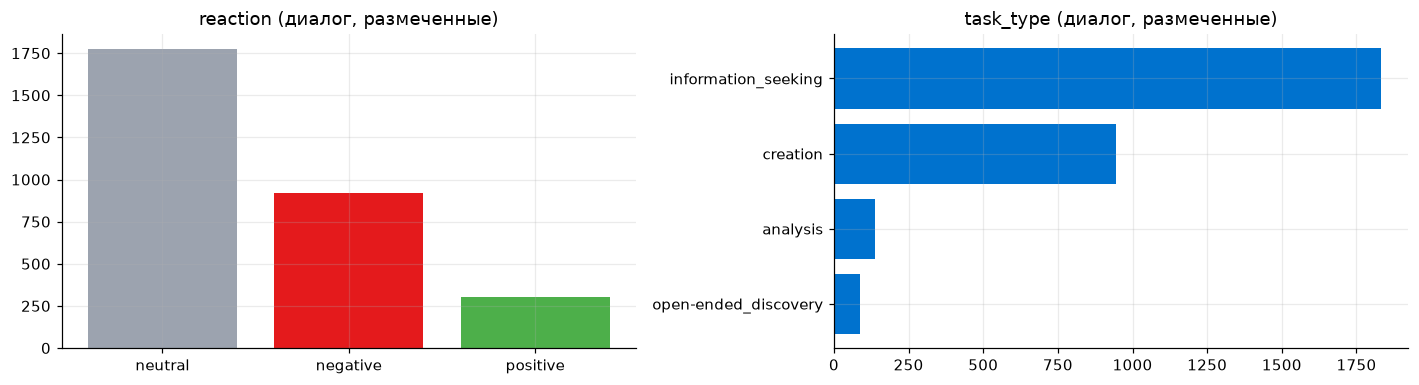

In [70]:
labeled = dialogs[dialogs["is_labeled"]].copy()
print(f"размечено {len(labeled)} из {len(dialogs)}")

for column in ["reaction", "task_type"]:
    counts = labeled[column].value_counts()
    shares = labeled[column].value_counts(normalize=True)
    display(pd.concat([counts.rename("диалогов"), shares.rename("доля")], axis=1).rename_axis(column))

reaction_counts = labeled["reaction"].value_counts()
print(f"accuracy тривиальной модели «всегда {reaction_counts.index[0]}»: {reaction_counts.iloc[0] / reaction_counts.sum():.3f}")
print(f"самый редкий класс ({reaction_counts.index[-1]}) в {reaction_counts.iloc[0] / reaction_counts.iloc[-1]:.1f} раза реже самого частого")

user_msgs = messages[messages["is_user"]]
lab_turns = user_msgs[user_msgs["dialog_id"].isin(labeled["dialog_id"])].copy()
print("\nреакции на уровне реплик (все реплики размеченных диалогов, кроме первых):")
display(lab_turns.loc[lab_turns["user_idx"] > 0, "turn_reaction"].value_counts(dropna=False).to_frame("реплик"))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
colors = [REACTION_COLORS.get(name, GREY) for name in reaction_counts.index]
axes[0].bar(reaction_counts.index, reaction_counts.to_numpy(), color=colors)
axes[0].set_title("reaction (диалог, размеченные)")
task_counts = labeled["task_type"].value_counts()
axes[1].barh(task_counts.index[::-1], task_counts.to_numpy()[::-1], color=BLUE)
axes[1].set_title("task_type (диалог, размеченные)")
plt.tight_layout()
plt.show()

### 7.2. Метки реплик и аномалии

**Логика.** Реакция — это отношение пользователя к *предыдущему* ответу модели, поэтому у первой реплики `reaction = null`. Проверяем это и другие правила, которые должны выполняться, и считаем нарушения. Заодно смотрим связь `state` ↔ `reaction` и `reaction_reason` ↔ `reaction`.

Что здесь можно ожидать (проверьте по таблицам):
- `feedback` ↔ чаще `negative`, `continuation` и `newtopic` ↔ `neutral`, `positive_closure` ↔ `positive`;
- у `neutral` причины нет; у `negative` и `positive` причина есть и своя для каждой полярности.

`state` и `reaction_reason` — тоже метки: на скрытом тесте их не будет, поэтому в признаки они не годятся. Их можно использовать как дополнительные цели или для разбора ошибок.

**Синтаксис.**
- `fillna("null")` превращает пропуск в видимую строку: иначе `crosstab` его выбросит.
- `ct.loc[ct.sum(axis=1).nlargest(15).index]` — оставляем 15 строк с наибольшей суммой (`nlargest`), чтобы длинный список причин не заслонил картину.
- `user_idx.eq(0)` — «номер реплики равен 0», то есть первая реплика.

In [71]:
first = lab_turns[lab_turns["user_idx"] == 0]
non_first = lab_turns[lab_turns["user_idx"] > 0]
polar = lab_turns["turn_reaction"].isin(["negative", "positive"])

anomalies = {
    "первая реплика: reaction не null": int(first["turn_reaction"].notna().sum()),
    "первая реплика: state не newtopic": int((first["turn_state"] != "newtopic").sum()),
    "не первая реплика: reaction = null": int(non_first["turn_reaction"].isna().sum()),
    "neutral, но причина задана": int(((lab_turns["turn_reaction"] == "neutral") & lab_turns["turn_reaction_reason"].notna()).sum()),
    "negative/positive без причины": int((polar & lab_turns["turn_reaction_reason"].isna()).sum()),
    "state = newtopic, но реакция negative/positive": int(((lab_turns["turn_state"] == "newtopic") & polar & (lab_turns["user_idx"] > 0)).sum()),
}
display(pd.Series(anomalies, name="реплик").to_frame())

print("значения state:")
display(lab_turns["turn_state"].value_counts(dropna=False).to_frame("реплик").T)
display(pd.crosstab(lab_turns["turn_state"].fillna("null"), lab_turns["turn_reaction"].fillna("null").rename("turn_reaction")))

ct = pd.crosstab(lab_turns["turn_reaction_reason"].fillna("null"), lab_turns["turn_reaction"].fillna("null").rename("turn_reaction"))
print("самые частые причины:")
display(ct.loc[ct.sum(axis=1).nlargest(15).index])

,реплик
первая реплика: reaction не null,0
первая реплика: state не newtopic,13
не первая реплика: reaction = null,0
"neutral, но причина задана",0
negative/positive без причины,9
"state = newtopic, но реакция negative/positive",28


значения state:


turn_state,continuation,newtopic,refinement,feedback,positive_closure,revision
реплик,10190,5690,2571,1577,21,2


turn_reaction,negative,neutral,null,positive
turn_state,,,,
continuation,435,9411,12,332
feedback,1253,176,1,147
newtopic,9,2675,2987,19
positive_closure,0,0,0,21
refinement,719,1835,0,17
revision,0,2,0,0


самые частые причины:


turn_reaction,negative,neutral,null,positive
turn_reaction_reason,,,,
null,9,14099,3000,0
Insufficient_Detail,852,0,0,1
Revision,491,0,0,0
Factual_Error,490,0,0,0
Negative_Feedback,283,0,0,0
Gratitude,0,0,0,188
Ignored,137,0,0,0
Acknowledgment,0,0,0,97
Style,70,0,0,1


### 7.3. Как диалоговая `reaction` связана с реакциями реплик

**Логика.** Перебираем правдоподобные правила и считаем, как часто каждое воспроизводит диалоговую метку:

- «`negative`, если была хотя бы одна негативная реплика; иначе `positive`, если была позитивная; иначе `neutral`»;
- то же, но позитив в приоритете;
- реакция последней **ненейтральной** реплики (если таких нет — `neutral`);
- «каких реплик больше, негативных или позитивных» (при ничьей — `negative`).

Отдельно смотрим **смешанные диалоги** (есть и негативная, и позитивная реплика): простые правила расходятся именно там, и по ним видно, как разрешены конфликты.

**Что исправлено.** Раньше доли считались по всем 10 000 диалогам, и неразмеченные засчитывались как «несовпадение» (отсюда 0.296 вместо ≈0.99). Теперь только по размеченным.

**Синтаксис.**
- `grouped.agg(lambda s: ...)` — своя функция для каждого диалога; `s.isin([...]).any()` — есть ли в группе хоть одно из значений.
- `df.join(other, on="dialog_id")` — присоединяет таблицу `other` (индекс — `dialog_id`) к столбцу `dialog_id`.
- Вложенный `np.where(a, x, np.where(b, y, z))` — цепочка «если-иначе-если-иначе».
- `pd.Series({имя: np.mean(pred == y) ...})` — словарь «правило → доля совпадений».

In [72]:
grouped = lab_turns.groupby("dialog_id")["turn_reaction"]
polar_values = ["negative", "positive"]
reaction_agg = pd.DataFrame({
    "n_negative": grouped.agg(lambda s: int((s == "negative").sum())),
    "n_positive": grouped.agg(lambda s: int((s == "positive").sum())),
    "last_polar": grouped.agg(lambda s: s[s.isin(polar_values)].iloc[-1] if s.isin(polar_values).any() else "neutral"),
})
labeled = labeled.drop(columns=[c for c in reaction_agg.columns if c in labeled.columns]).join(reaction_agg, on="dialog_id")
labeled["any_negative"] = labeled["n_negative"] > 0
labeled["any_positive"] = labeled["n_positive"] > 0
y = labeled["reaction"].to_numpy()

rules = {
    "негатив в приоритете": np.where(labeled["any_negative"], "negative", np.where(labeled["any_positive"], "positive", "neutral")),
    "позитив в приоритете": np.where(labeled["any_positive"], "positive", np.where(labeled["any_negative"], "negative", "neutral")),
    "последняя ненейтральная реакция": labeled["last_polar"].to_numpy(),
    "негативных не меньше, чем позитивных": np.where((labeled["n_negative"] + labeled["n_positive"]) == 0, "neutral",
                                                      np.where(labeled["n_negative"] >= labeled["n_positive"], "negative", "positive")),
}
mixed = (labeled["any_negative"] & labeled["any_positive"]).to_numpy()
agreement = pd.DataFrame({
    "все размеченные": {name: np.mean(pred == y) for name, pred in rules.items()},
    "только смешанные": {name: (np.mean(pred[mixed] == y[mixed]) if mixed.any() else np.nan) for name, pred in rules.items()},
})
print(f"размеченных диалогов: {len(labeled)}, смешанных (есть и negative, и positive): {int(mixed.sum())}")
display(show_table(agreement, digits=3, axis=None))
display(pd.crosstab(labeled["reaction"], pd.Series(rules["негатив в приоритете"], index=labeled.index, name="правило «негатив в приоритете»")))
display(pd.crosstab(labeled.loc[mixed, "reaction"], "смешанные диалоги"))

размеченных диалогов: 3000, смешанных (есть и negative, и positive): 82


,все размеченные,только смешанные
негатив в приоритете,0.988,0.561
позитив в приоритете,0.985,0.439
последняя ненейтральная реакция,1.000,1.000
"негативных не меньше, чем позитивных",0.990,0.634


правило «негатив в приоритете»,negative,neutral,positive
reaction,,,
negative,923,0,0
neutral,0,1774,0
positive,36,0,267


col_0,смешанные диалоги
reaction,
negative,46
positive,36


### 7.4. Как диалоговый `task_type` связан с `task_type` реплик

**Логика.** Та же идея: диалоговый тип задачи — самый частый тип среди реплик, первый или последний? Это пригодится для задачи 2: тему диалога можно будет собирать из реплик. Опять только размеченные.

**Синтаксис.** `s.mode()` — самое частое значение (при ничьей их несколько, берем `.iloc[0]`); `.first()` / `.last()` — первое / последнее в группе.

In [73]:
task_group = lab_turns.groupby("dialog_id")["turn_task_type"]
task_agg = pd.DataFrame({
    "mode_task": task_group.agg(lambda s: s.mode().iloc[0] if s.notna().any() else np.nan),
    "first_task": task_group.first(),
    "last_task": task_group.last(),
})
task_frame = labeled[["dialog_id", "task_type"]].join(task_agg, on="dialog_id")
task_agreement = pd.Series({
    "самый частый тип среди реплик": (task_frame["mode_task"] == task_frame["task_type"]).mean(),
    "тип первой реплики": (task_frame["first_task"] == task_frame["task_type"]).mean(),
    "тип последней реплики": (task_frame["last_task"] == task_frame["task_type"]).mean(),
}, name="доля совпадений с task_type диалога")
display(show_table(task_agreement.to_frame(), axis=None))
display(pd.crosstab(task_frame["task_type"], task_frame["mode_task"].rename("самый частый тип реплик")))

,доля совпадений с task_type диалога
самый частый тип среди реплик,0.977
тип первой реплики,0.822
тип последней реплики,0.807


самый частый тип реплик,analysis,creation,information_seeking,open-ended_discovery
task_type,,,,
analysis,137,0,0,0
creation,4,940,0,0
information_seeking,21,33,1777,0
open-ended_discovery,1,0,10,77


### 7.5. Где в диалоге сидит сигнал реакции

**Логика.** Если диалоговая метка — «был ли хоть один недовольный или довольный момент», то признак нужно искать в отдельных репликах, а не в диалоге целиком. Проверяем это тремя способами:

1. Сколько реплик в диалоге каждого класса несут негативную или позитивную реакцию и какова их доля среди реплик диалога (если, например, 1–2 реплики из 6–10, то при векторизации всего диалога сигнал разбавляется остальными).
2. **В какой части диалога** встречаются такие реплики: распределение относительной позиции `user_idx / (n − 1)` (0 — начало, 1 — конец). Если пики у конца, то последние реплики информативнее; если равномерно, то нет.
3. Сохраняем агрегаты в основную таблицу `dialogs`, чтобы использовать их позже.

**Синтаксис.**
- `labeled.groupby("reaction")[[...]].mean()` — среднее по нескольким столбцам внутри каждого класса.
- `series.map(dict_or_series)` — подстановка значения по ключу (здесь число реплик диалога по `dialog_id`).
- `ax.hist(..., density=True)` — гистограмма, нормированная на площадь 1, чтобы сравнивать классы разного размера.

,n_negative,n_positive,n_polar,polar_share
reaction,,,,
negative,2.55,0.06,2.61,0.46
neutral,0.00,0.00,0.00,0.00
positive,0.20,1.60,1.80,0.32


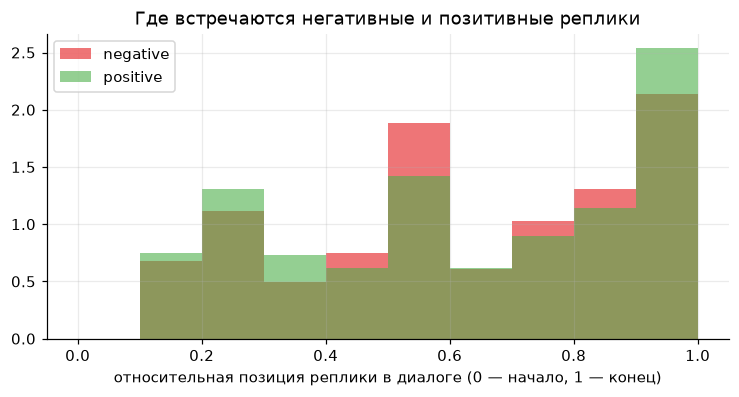

In [74]:
labeled["n_polar"] = labeled["n_negative"] + labeled["n_positive"]
labeled["polar_share"] = labeled["n_polar"] / (labeled["n_user_actual"] - 1)   # доля реплик (кроме первой) с реакцией
display(labeled.groupby("reaction")[["n_negative", "n_positive", "n_polar", "polar_share"]].mean().round(2))

n_user_by_dialog = dialogs.set_index("dialog_id")["n_user_actual"]
polar_turns = lab_turns[lab_turns["turn_reaction"].isin(["negative", "positive"])].copy()
polar_turns["rel_pos"] = polar_turns["user_idx"] / (polar_turns["dialog_id"].map(n_user_by_dialog) - 1)

fig, ax = plt.subplots(figsize=(8, 3.6))
for cls in ["negative", "positive"]:
    ax.hist(polar_turns.loc[polar_turns["turn_reaction"] == cls, "rel_pos"], bins=10, range=(0, 1), alpha=0.6, density=True,
            color=REACTION_COLORS[cls], label=cls)
ax.set_xlabel("относительная позиция реплики в диалоге (0 — начало, 1 — конец)")
ax.set_title("Где встречаются негативные и позитивные реплики")
ax.legend()
plt.show()

for column in ["n_negative", "n_positive", "last_polar", "n_polar", "polar_share"]:
    dialogs[column] = dialogs["dialog_id"].map(labeled.set_index("dialog_id")[column])

## 8. Что связано с реакцией и проверка гипотез (только размеченные)

**Логика.** Как в разделе 5 семинара: доли классов внутри групп **вместе с размером группы** (доля по двадцати диалогам ничего не значит), потом корреляция Спирмена. Реакция ординальна (негатив < нейтрал < позитив), поэтому для корреляции кодируем её −1/0/+1; это допущение. Связь не причина.

**Что изменилось.** В данных только диалоги с 5–10 репликами пользователя, поэтому прежние интервалы (1, 2, 3, 4–5, …) давали две пустые клетки; теперь группируем по реальному значению `n_user_actual`.

В этом разделе три проверки гипотез, которые мы выдвинули по итогам первого прогона:

- **Г1.** Сигнал реакции сидит в 1–2 репликах (раздел 7.5), а не в диалоге целиком.
- **Г2.** Текст ассистента может быть признаком: после жалобы модель обычно извиняется («I apologize…»). Проверяем долю ответов с извинением после реплик пользователя разных реакций.
- **Г3.** Длина диалога и дубликатность слабо связаны с реакцией.

**Синтаксис.**
- `str.contains(r"\b(?:apologi[sz]e|apologies|sorry)\b", case=False, regex=True)` — поиск слов целиком (`\b` — граница слова), `(?:a|b)` — «a или b», `[sz]` — «s или z» (британское и американское написание), `case=False` — без учета регистра.
- `groupby("dialog_id")["turn_reaction"].shift(1)` — значение из предыдущей строки той же группы; у ответа ассистента предыдущая строка — реплика пользователя, на которую он отвечает.
- `.corr(method="spearman")` — корреляция рангов.

In [75]:
# --- новые признаки уровня диалога
role_chars = messages.pivot_table(index="dialog_id", columns="role", values="n_chars", aggfunc="sum")
dialogs["assistant_char_share"] = dialogs["dialog_id"].map(role_chars["assistant"] / (role_chars["assistant"] + role_chars["user"]))

messages["is_assistant"] = messages["role"] == "assistant"
messages["has_apology"] = messages["is_assistant"] & messages["text"].str.contains(r"\b(?:apologi[sz]e|apologies|sorry)\b", case=False, regex=True)
dialogs["n_apology"] = dialogs["dialog_id"].map(messages.groupby("dialog_id")["has_apology"].sum())
messages["prev_reaction"] = messages.groupby("dialog_id")["turn_reaction"].shift(1)

labeled = dialogs[dialogs["is_labeled"]].copy()          # обновляем: теперь в ней все новые столбцы

# --- связь с длиной диалога и языком (по реальным значениям, с размерами групп)
print("число диалогов в каждой клетке:")
display(pd.crosstab(labeled["n_user_actual"], labeled["reaction"]))
print("доли классов внутри групп по числу реплик:")
display(show_table(pd.crosstab(labeled["n_user_actual"], labeled["reaction"], normalize="index"), digits=2, axis=None))
print("язык (число диалогов и доли):")
display(pd.crosstab(labeled["language"], labeled["reaction"]))
display(show_table(pd.crosstab(labeled["language"], labeled["reaction"], normalize="index"), digits=2, axis=None))

# --- Спирмен
numeric = pd.DataFrame({
    "reaction (−1/0/+1)": labeled["reaction"].map({"negative": -1, "neutral": 0, "positive": 1}),
    "реплик пользователя": labeled["n_user_actual"],
    "log10(символов)": np.log10(labeled["n_chars_total"] + 1),
    "доля символов ассистента": labeled["assistant_char_share"],
    "близость к соседу": labeled["nn_sim"],
    "есть код": labeled["has_code"].astype(int),
    "есть петля ассистента": labeled["has_assistant_loop"].astype(int),
    "извинений ассистента": labeled["n_apology"],
})
print("корреляция Спирмена с реакцией:")
display(show_table(numeric.corr(method="spearman")[["reaction (−1/0/+1)"]], digits=2, axis=None))

число диалогов в каждой клетке:


reaction,negative,neutral,positive
n_user_actual,,,
5,252,562,85
6,231,431,59
7,162,297,60
8,128,206,38
9,83,151,35
10,67,127,26


доли классов внутри групп по числу реплик:


reaction,negative,neutral,positive
n_user_actual,,,
5,0.28,0.63,0.09
6,0.32,0.60,0.08
7,0.31,0.57,0.12
8,0.34,0.55,0.10
9,0.31,0.56,0.13
10,0.30,0.58,0.12


язык (число диалогов и доли):


reaction,negative,neutral,positive
language,,,
en,916,1760,302
ru,7,14,1


reaction,negative,neutral,positive
language,,,
en,0.31,0.59,0.10
ru,0.32,0.64,0.05


корреляция Спирмена с реакцией:


,reaction (−1/0/+1)
reaction (−1/0/+1),1.00
реплик пользователя,-0.01
log10(символов),-0.06
доля символов ассистента,0.05
близость к соседу,-0.10
есть код,-0.30
есть петля ассистента,-0.06
извинений ассистента,-0.42


**Проверка Г2: извинения ассистента.** Берем все ответы ассистента в размеченных диалогах и смотрим, как часто в них встречается извинение в зависимости от реакции **предыдущей реплики пользователя**. Если после негативной реплики доля извинений намного выше, то текст ассистента — хороший косвенный индикатор жалобы.

**Что исправлено/добавлено** по сравнению с первой версией: сама проверка.

In [76]:
replies = messages[messages["is_assistant"] & messages["dialog_id"].isin(labeled["dialog_id"])]
apology_table = replies.groupby(replies["prev_reaction"].fillna("нет (первый ответ)"))["has_apology"].agg(["mean", "size"])
apology_table.columns = ["доля ответов с извинением", "ответов"]
display(show_table(apology_table, digits=3))

print("доля диалогов с хотя бы одним извинением, по классам реакции диалога:")
display(labeled.assign(has_apology=labeled["n_apology"] > 0).groupby("reaction")["has_apology"].mean().round(3).to_frame("доля"))
print("петля ассистента и код, доля по классам реакции:")
display(labeled.groupby("reaction")[["has_assistant_loop", "has_code", "has_user_code"]].mean().round(3))

,доля ответов с извинением,ответов
prev_reaction,,
negative,0.526,2416
neutral,0.053,14099
positive,0.043,536
нет (первый ответ),0.030,3000


доля диалогов с хотя бы одним извинением, по классам реакции диалога:


,доля
reaction,
negative,0.671
neutral,0.172
positive,0.307


петля ассистента и код, доля по классам реакции:


,has_assistant_loop,has_code,has_user_code
reaction,,,
negative,0.028,0.484,0.144
neutral,0.012,0.172,0.036
positive,0.010,0.168,0.036


### Слова: какие признаки отличают классы

**Логика.** Для каждого класса находим слова и биграммы, у которых средний TF-IDF в классе больше всего превышает средний TF-IDF вне класса (функция `top_distinctive`). Делаем это дважды:

- по **последней реплике пользователя** диалога (метка — реакция диалога);
- по **всем репликам, кроме первой** (метка — реакция самой реплики). Реплик намного больше, чем диалогов, и метка точнее: она относится к конкретной реплике.

Стоп-слова **не убираем**: семинар предупреждает, что вместе с ними пропадает отрицание.

**Синтаксис.**
- `ngram_range=(1, 2)` — слова и пары соседних слов; `min_df` — слово должно встретиться хотя бы в стольких текстах (отсекает опечатки); `sublinear_tf=True` — `1 + ln(частота)`.
- `matrix[mask].mean(axis=0)` — среднее по строкам выбранных объектов; результат — матрица 1×словарь, `np.asarray(...).ravel()` делает из нее вектор.
- `np.argsort(diff)[::-1][:n]` — номера `n` слов с наибольшей разностью.

In [77]:
def top_distinctive(texts, labels, classes, min_df, n=10):
    # Для каждого класса: слова с наибольшей разностью среднего TF-IDF внутри класса и вне его.
    vectorizer = TfidfVectorizer(min_df=min_df, ngram_range=(1, 2), sublinear_tf=True, max_features=50000)
    matrix = vectorizer.fit_transform(texts)
    vocab = vectorizer.get_feature_names_out()
    result = {}
    for cls in classes:
        mask = (labels == cls).to_numpy()
        if mask.sum() == 0 or (~mask).sum() == 0:
            continue
        diff = np.asarray(matrix[mask].mean(axis=0)).ravel() - np.asarray(matrix[~mask].mean(axis=0)).ravel()
        result[cls] = vocab[np.argsort(diff)[::-1][:n]]
    return pd.DataFrame(result)


classes = ["negative", "neutral", "positive"]
print("последняя реплика пользователя → реакция диалога:")
display(top_distinctive(labeled["last_user_text"].str[:1000], labeled["reaction"], classes, min_df=3))

turns_lab = lab_turns[lab_turns["user_idx"] > 0]
print("все реплики пользователя (кроме первой) → реакция реплики:")
display(top_distinctive(turns_lab["text"].str[:1000], turns_lab["turn_reaction"], classes, min_df=5))

последняя реплика пользователя → реакция диалога:


,negative,neutral,positive
0,error,write,thanks
1,not,and,you
2,code,of,thank you
3,no,to,thank
4,still,how,ok
5,file,in,you for
6,wrong,the,good
7,line,what,can you
8,is not,are,bye
9,try,with,goodbye


все реплики пользователя (кроме первой) → реакция реплики:


,negative,neutral,positive
0,not,what,thanks
1,error,of,thank you
2,no,and,thank
3,still,how,you
4,again,to,ok
5,wrong,write,good
6,is not,what is,great
7,line,about,you for
8,it,in,like
9,try,with,but


## 9. Флаги качества, две политики чистки, обрезка текстов

### 9.1. Флаги

**Логика.** Как в разделе 3 семинара: сначала **помечаем** проблемы флагами, потом отдельной строкой выбираем, что убирать. Новое по сравнению с первой версией: флаг `unlabeled` и разные политики для задач 1 и 2.

| Флаг | Что значит |
|:--|:--|
| `unlabeled` | нет меток (70% диалогов) |
| `is_exact_dup` | точная копия более раннего диалога |
| `bad_roles` | сломан порядок ролей или нет реплик пользователя |
| `bad_label_count` | диалог размечен, но число меток реплик не равно числу реплик |
| `has_empty_message` | есть пустая реплика |
| `has_code`, `has_assistant_loop` | есть код / ассистент повторяет ответ |
| `is_template` | первая реплика повторяется ≥ 5 раз (кроме пустой) |
| `in_near_dup_group` | диалог в группе почти-копий (порог из 6.4) |

**Синтаксис.** `dialogs[FLAGS].sum()` / `.mean()` — для каждого столбца-флага число и доля `True`.

In [78]:
dialogs["unlabeled"] = ~dialogs["is_labeled"]
dialogs["has_empty_message"] = dialogs["dialog_id"].isin(messages.loc[is_empty, "dialog_id"])
dialogs["is_exact_dup"] = dialogs.duplicated("full_text")
dialogs["bad_roles"] = dialogs["dialog_id"].isin(bad_roles_ids) | (dialogs["n_user_actual"] == 0)
dialogs["bad_label_count"] = dialogs["is_labeled"] & (dialogs["n_label_turns"] != dialogs["n_user_actual"])
dialogs["is_template"] = (dialogs["first_turn_freq"] >= 5) & (dialogs["first_user_norm"] != "")

FLAGS = ["unlabeled", "is_exact_dup", "bad_roles", "bad_label_count", "has_empty_message",
         "has_code", "has_assistant_loop", "is_template", "in_near_dup_group"]
flag_table = pd.DataFrame({"диалогов": dialogs[FLAGS].sum(), "доля": dialogs[FLAGS].mean()})
display(show_table(flag_table, axis=0))

,диалогов,доля
unlabeled,7000,0.700
is_exact_dup,0,0.000
bad_roles,0,0.000
bad_label_count,0,0.000
has_empty_message,0,0.000
has_code,2697,0.270
has_assistant_loop,167,0.017
is_template,0,0.000
in_near_dup_group,298,0.030


### 9.2. Две политики

| Флаг | Задача 1 (реакция) | Задача 2 (темы) | Почему |
|:--|:--|:--|:--|
| `unlabeled` | **убираем** | **оставляем** | для обучения реакции нужна метка; для тем метки не нужны, а данных больше |
| `is_exact_dup` | убираем | убираем | копия в обучении и тесте завышает метрики |
| `bad_roles` | убираем | убираем | непонятно, чья реплика чья |
| `bad_label_count` | убираем | оставляем | метки реплик не выровнены, но диалог для тем пригоден |
| `has_empty_message`, `has_code`, `has_assistant_loop`, `is_template` | оставляем | оставляем | в скрытом тесте такое тоже будет; обрезаем и помечаем, но не удаляем |
| `in_near_dup_group` | оставляем, группируем (`group_id`) | оставляем | удалять нельзя, но делить по `GroupKFold` нужно |

**Что видно в таблице «до / после» ниже.** В первой версии значения `до` и `после` совпадали, потому что `value_counts` пропускает `NaN` и неразмеченные диалоги просто не попадали в подсчет. Теперь неразмеченные показаны явной строкой «нет метки».

**Синтаксис.** `dialogs[DROP].any(axis=1)` — для каждой строки: истинен ли хотя бы один флаг из списка; `~` — «ни один». `fillna("нет метки")` — подпись для пропусков; `.fillna(0).astype(int)` — после склейки таблиц пустые клетки становятся нулями.

In [79]:
DROP_COMMON = ["is_exact_dup", "bad_roles"]
dialogs["use_topics"] = ~dialogs[DROP_COMMON].any(axis=1)
dialogs["use_reaction"] = dialogs["use_topics"] & dialogs["is_labeled"] & ~dialogs["bad_label_count"]

print(f"всего: {len(dialogs)};  для задачи 2 (темы): {int(dialogs['use_topics'].sum())};  для задачи 1 (реакция): {int(dialogs['use_reaction'].sum())}")
before = dialogs["reaction"].fillna("нет метки").value_counts()
after = dialogs.loc[dialogs["use_reaction"], "reaction"].value_counts()
display(pd.DataFrame({"все диалоги": before, "для задачи 1": after}).fillna(0).astype(int))

всего: 10000;  для задачи 2 (темы): 10000;  для задачи 1 (реакция): 3000


,все диалоги,для задачи 1
reaction,,
negative,923,923
neutral,1774,1774
positive,303,303
нет метки,7000,0


### 9.3. Обрезка длинных реплик

**Логика.** Мы не удаляем диалоги с длинными вставками, но при векторизации тексты придется **обрезать**: ноутбук должен уложиться в 10 минут на CPU. Подбираем длину среза `cap` по числам: какую долю реплик затронет обрезка и какая доля символов сохранится. Хорошая граница — где доля сохраненных символов еще высока, а число обрезанных реплик невелико. Считаем отдельно для пользователя и ассистента.

**Синтаксис.** `series.clip(upper=cap)` — значения больше `cap` заменяются на `cap`, то есть длина после обрезки; `(series > cap).mean()` — доля реплик длиннее `cap`.

In [80]:
rows = []
for role in ["user", "assistant"]:
    lengths = messages.loc[messages["role"] == role, "n_chars"]
    for cap in [300, 500, 1000, 2000, 4000]:
        rows.append({"роль": role, "обрезка до, символов": cap,
                     "затронуто реплик": (lengths > cap).mean(),
                     "сохранено символов": lengths.clip(upper=cap).sum() / lengths.sum()})
display(show_table(pd.DataFrame(rows).set_index(["роль", "обрезка до, символов"]), digits=3))

### 9.4. Сохраняем результат

Флаги, политики, `group_id` и агрегаты меток (без текстов, чтобы файл был маленьким) пригодятся в следующих ноутбуках: из них возьмем списки диалогов для задач 1 и 2 и группы для кросс-валидации.

**Синтаксис.** `df.drop(columns=[...])` — убрать столбцы; `to_csv(path, index=False)` — записать в csv без номера строки.

In [83]:
text_columns = ["first_user_text", "last_user_text", "user_text", "full_text", "first_user_norm"]
dialogs.drop(columns=text_columns).to_csv("dialog_flags.csv", index=False)
print("сохранено: dialog_flags.csv,", dialogs.shape[0], "строк,", dialogs.shape[1] - len(text_columns), "столбцов")

сохранено: dialog_flags.csv, 10000 строк, 35 столбцов


## 10. Что вынести в отчет и что мы узнали

**Что вынести в `README.md` (раздел «Разведочный анализ и чистка»):** для каждого пункта число, один-два примера (id и начало текста) и решение с причиной.

1. Размер и формат; проверки структуры (раздел 2.1).
2. **Разметка: 3000 из 10 000.** Случайна ли размеченная часть (2.2). Следствие: задача 1 на 3000, задача 2 на 10 000.
3. Длины: медианы и 99-й перцентиль по ролям; доля символов ассистента; выбросы снизу и сверху на двух шкалах, пояснение, почему они различаются (раздел 3); решение об обрезке (9.3).
4. Языки; ограничения (мало русского).
5. Мусор: код, петли, шаблоны, пустые реплики; для каждого, сколько и что делаем.
6. Дубли: точные, одинаковые первые реплики, почти-копии (порог, групп, доля совпадения реакции против случайного уровня).
7. Метки: дисбаланс (в обучении neutral ≈ 59%, negative ≈ 31%, positive ≈ 10%), аномалии, как диалоговая метка получается из меток реплик (7.3–7.5).
8. Проверка гипотез Г1–Г3 (раздел 8).
9. Политики чистки (9.2) с итоговыми числами.

**Что уже известно из первого прогона** (числа подтвердятся при перезапуске):
- в данных нет пустых реплик, точных дублей, нарушений структуры; все диалоги от 5 до 10 реплик пользователя; почти-копий около 1.5% при пороге 0.9;
- в 4/5 символов диалога — текст ассистента;
- в размеченных диалогах метка `reaction` согласована с метками реплик почти полностью по правилу «есть ненейтральная реплика → диалог не neutral»;
- для задачи 1 доступно всего 3000 диалогов, для задачи 2 — 10 000.

**Гипотезы для следующего этапа** (на бонусные баллы за «свою гипотезу»):
1. Сигнал реакции в 1–2 репликах: модель на уровне реплики + агрегация «максимум по диалогу» против модели на всем диалоге.
2. Какая часть диалога лучше всего предсказывает реакцию: весь текст, только пользователь, только последняя реплика, пользователь + ответ ассистента после реплики.
3. Извинения ассистента как косвенный признак жалобы (проверка в разделе 8).
4. Сдвиг классов между обучением и скрытым тестом: взвешивание классов, поправка вероятностей на априорное распределение, macro-F1 и сбалансированная accuracy.

**Следствия для задач.** Деление с `group_id` (`StratifiedGroupKFold`); метрика реакции — macro-F1 (accuracy обманывает при дисбалансе); предобработка должна выдерживать пустые реплики и огромные вставки: в скрытом тесте их не вычищали.